In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt

/home/ailab/.local/lib/python3.10/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# get data
dataset, info = tfds.load('oxford_iiit_pet:3.*.*', with_info=True)

2023-01-13 12:18:19.911338: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-13 12:18:19.915101: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-13 12:18:19.915260: I tensorflow/stream_executor/cuda/cuda_gpu_executor.cc:936] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2023-01-13 12:18:19.915563: I tensorflow/core/platform/cpu_feature_guard.cc:151] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags

In [3]:
# process data

def normalize(input_image, input_mask):
    input_image = tf.cast(input_image, tf.float32) / 255.0
    input_mask -= 1
    return input_image, input_mask

@tf.function
def load_image_train(datapoint):
    input_image = tf.image.resize(datapoint['image'], (128, 128))
    input_mask = tf.image.resize(datapoint['segmentation_mask'], (128, 128))

    if tf.random.uniform(()) > 0.5:
        input_image = tf.image.flip_left_right(input_image)
        input_mask = tf.image.flip_left_right(input_mask)

    input_image, input_mask = normalize(input_image, input_mask)
    return input_image, input_mask

def load_image_test(datapoint):
    input_image = tf.image.resize(datapoint['image'], (128, 128))
    input_mask = tf.image.resize(datapoint['segmentation_mask'], (128, 128))

    input_image, input_mask = normalize(input_image, input_mask)

    return input_image, input_mask

In [4]:
TRAIN_LENGTH = info.splits['train'].num_examples
BATCH_SIZE = 4
BUFFER_SIZE = 1000
STEPS_PER_EPOCH = TRAIN_LENGTH // BATCH_SIZE

train = dataset['train'].map(load_image_train, num_parallel_calls=tf.data.AUTOTUNE)
test = dataset['test'].map(load_image_test)

train_dataset = train.cache().shuffle(BUFFER_SIZE).batch(BATCH_SIZE).repeat()
train_dataset = train_dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
test_dataset = test.batch(BATCH_SIZE)

In [5]:
# monitor
def display(display_list):
    plt.figure(figsize=(15, 15))

    title = ['Input Image', 'True Mask', 'Predicted Mask']

    for i in range(len(display_list)):
        plt.subplot(1, len(display_list), i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.preprocessing.image.array_to_img(display_list[i]))
        plt.axis('off')
    plt.show()

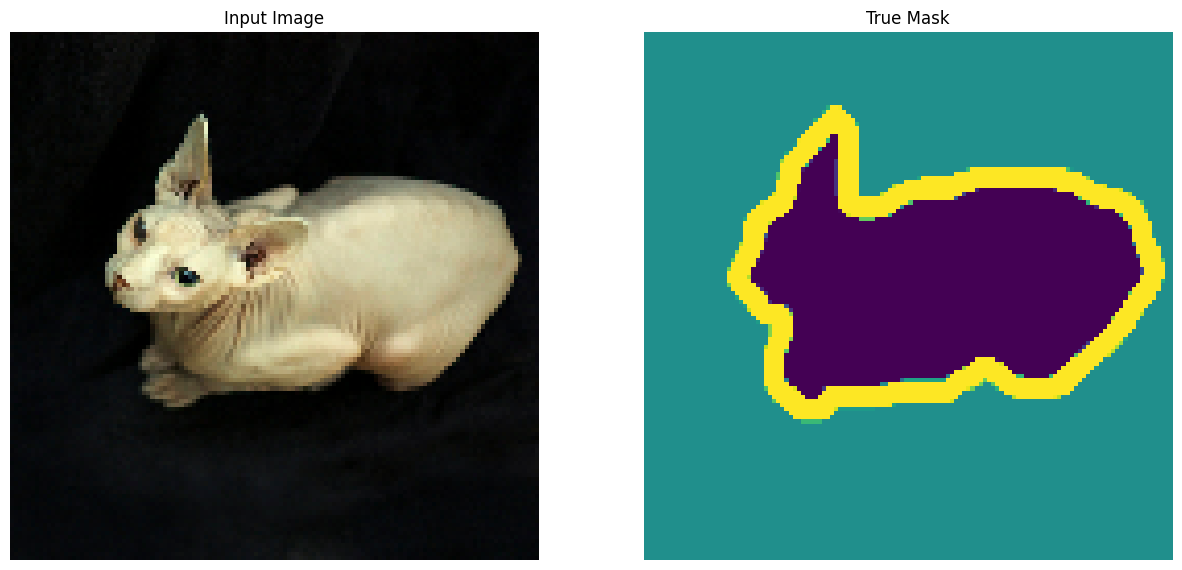

In [6]:
for image, mask in train.take(1):
    sample_image, sample_mask = image, mask
    display([sample_image, sample_mask])

In [10]:
model = tf.keras.Sequential()    

# block 1
model.add(tf.keras.layers.Conv2D(64, 9, padding='same', activation='LeakyReLU', input_shape=(128, 128, 3)))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D())

# block 2
model.add(tf.keras.layers.Conv2D(128, 9, padding='same', activation='LeakyReLU'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D())

# block 3
model.add(tf.keras.layers.Conv2D(256, 5, padding='same', activation='LeakyReLU'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D())

# block 4
model.add(tf.keras.layers.Conv2D(512, 5, padding='same', activation='LeakyReLU'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D())

# block 5
model.add(tf.keras.layers.Conv2D(512, 3, padding='same', activation='LeakyReLU'))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.MaxPooling2D())

# upsampling
model.add(tf.keras.layers.UpSampling2D())
model.add(tf.keras.layers.Conv2D(256, 3, padding='same', activation='LeakyReLU'))
model.add(tf.keras.layers.BatchNormalization())

model.add(tf.keras.layers.UpSampling2D())
model.add(tf.keras.layers.Conv2D(128, 3, padding='same', activation='LeakyReLU'))
model.add(tf.keras.layers.BatchNormalization())

model.add(tf.keras.layers.UpSampling2D())
model.add(tf.keras.layers.Conv2D(64, 3, padding='same', activation='LeakyReLU'))
model.add(tf.keras.layers.BatchNormalization())

model.add(tf.keras.layers.UpSampling2D())
model.add(tf.keras.layers.Conv2D(32, 3, padding='same', activation='LeakyReLU'))
model.add(tf.keras.layers.BatchNormalization())

model.add(tf.keras.layers.UpSampling2D())
model.add(tf.keras.layers.Conv2D(3, 3, padding='same'))

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_10 (Conv2D)          (None, 128, 128, 64)      15616     
                                                                 
 batch_normalization_9 (Batc  (None, 128, 128, 64)     256       
 hNormalization)                                                 
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 64, 64, 64)       0         
 2D)                                                             
                                                                 
 conv2d_11 (Conv2D)          (None, 64, 64, 128)       663680    
                                                                 
 batch_normalization_10 (Bat  (None, 64, 64, 128)      512       
 chNormalization)                                                
                                                      

In [11]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

def create_mask(pred_mask):
    pred_mask = tf.argmax(pred_mask, axis=-1)
    pred_mask = pred_mask[..., tf.newaxis]
    
    return pred_mask[0]

def show_predictions(dataset=None, num=1):
    if dataset:
        for image, mask in dataset.take(num):
            pred_mask = model.predict(image)
            display([image[0], mask[0], create_mask(pred_mask)])
    else:
        display([sample_image, sample_mask,
                 create_mask(model.predict(sample_image[tf.newaxis, ...]))])
        
class DisplayCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):        
        show_predictions()
        print ('\nSample Prediction after epoch {}\n'.format(epoch+1))

Epoch 1/20


Corrupt JPEG data: 240 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
2023-01-13 12:19:44.075383: I tensorflow/stream_executor/cuda/cuda_dnn.cc:368] Loaded cuDNN version 8100
2023-01-13 12:19:44.550071: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-01-13 12:19:44.550466: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-01-13 12:19:44.550477: W tensorflow/stream_executor/gpu/asm_compiler.cc:80] Couldn't get ptxas version string: INTERNAL: Couldn't invoke ptxas --version
2023-01-13 12:19:44.550996: I tensorflow/core/platform/default/subprocess.cc:304] Start cannot spawn child process: No such file or directory
2023-01-13 12:19:44.551032: W tensorflow/stream_executor/gpu/redzone_allocator.cc:314] INTERNAL: Failed to launch ptxas
Relying on driver to perform ptx compilation. 
Modify $PATH to customize ptxas loca

917/920 [============================>.] - ETA: 0s - loss: 0.7294 - accuracy: 0.7027

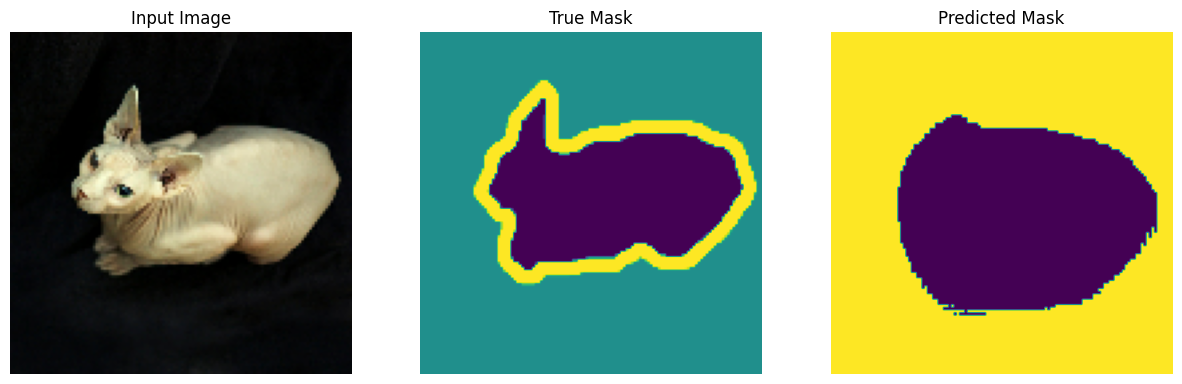


Sample Prediction after epoch 1

920/920 [==============================] - 20s 18ms/step - loss: 0.7291 - accuracy: 0.7029 - val_loss: 0.6977 - val_accuracy: 0.7336
Epoch 2/20
917/920 [============================>.] - ETA: 0s - loss: 0.6142 - accuracy: 0.7490

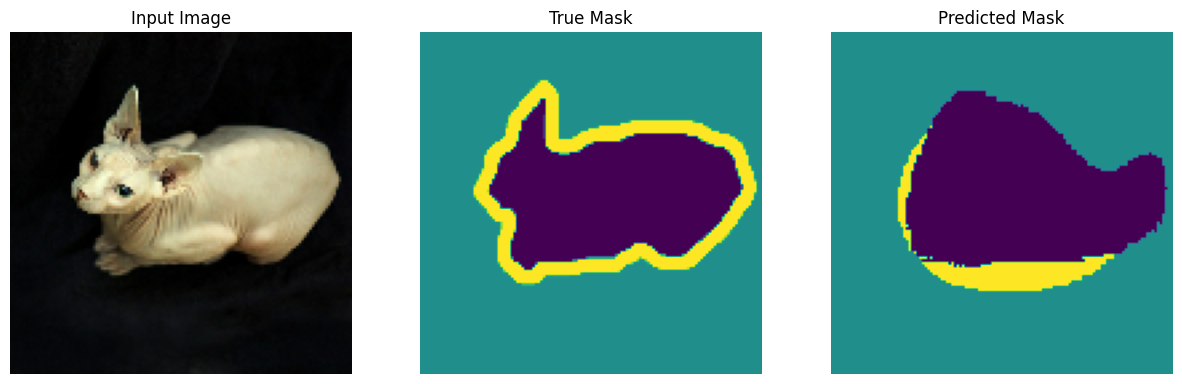


Sample Prediction after epoch 2

920/920 [==============================] - 16s 17ms/step - loss: 0.6143 - accuracy: 0.7489 - val_loss: 0.6165 - val_accuracy: 0.7505
Epoch 3/20
920/920 [==============================] - ETA: 0s - loss: 0.5721 - accuracy: 0.7654

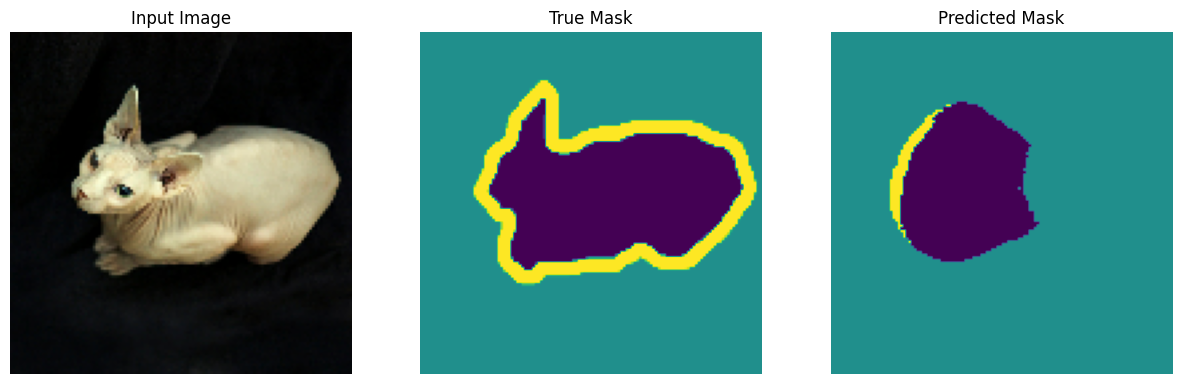


Sample Prediction after epoch 3

920/920 [==============================] - 16s 17ms/step - loss: 0.5721 - accuracy: 0.7654 - val_loss: 0.6893 - val_accuracy: 0.7400
Epoch 4/20
918/920 [============================>.] - ETA: 0s - loss: 0.5399 - accuracy: 0.7780

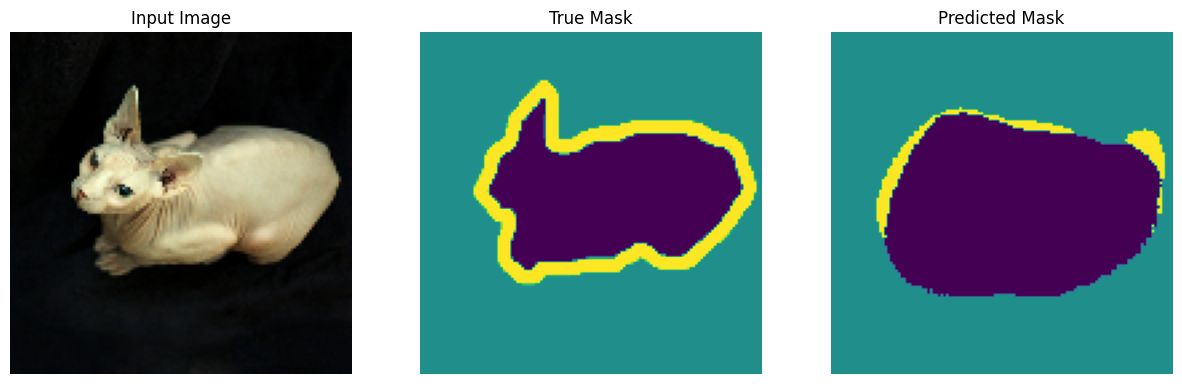


Sample Prediction after epoch 4

920/920 [==============================] - 16s 17ms/step - loss: 0.5398 - accuracy: 0.7781 - val_loss: 0.6759 - val_accuracy: 0.7429
Epoch 5/20
920/920 [==============================] - ETA: 0s - loss: 0.5153 - accuracy: 0.7877

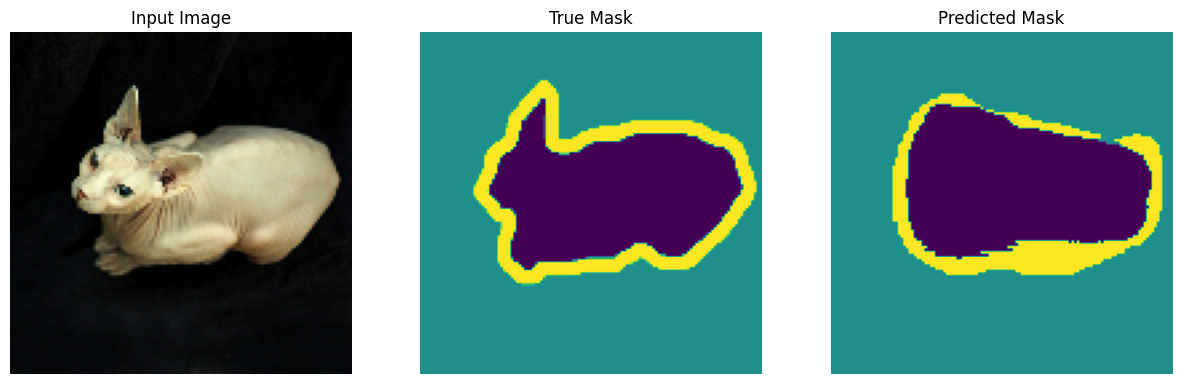


Sample Prediction after epoch 5

920/920 [==============================] - 16s 17ms/step - loss: 0.5153 - accuracy: 0.7877 - val_loss: 0.5255 - val_accuracy: 0.7854
Epoch 6/20
920/920 [==============================] - ETA: 0s - loss: 0.4845 - accuracy: 0.8004

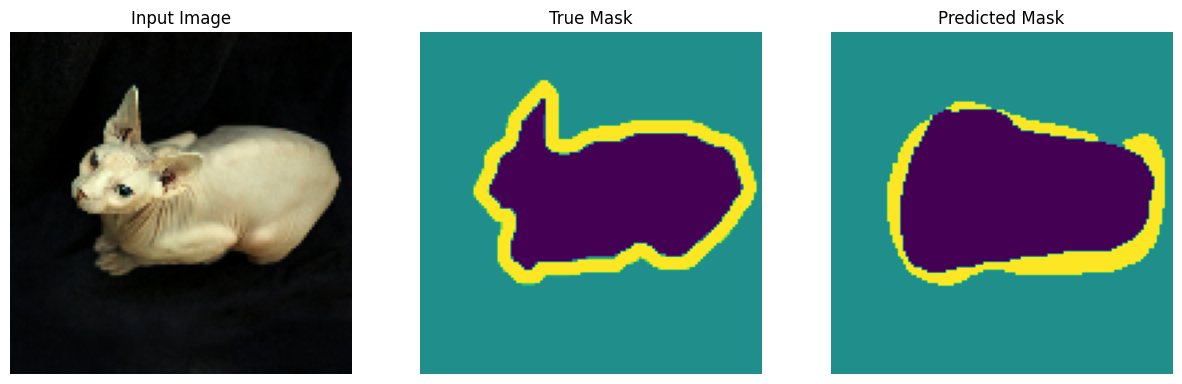


Sample Prediction after epoch 6

920/920 [==============================] - 16s 17ms/step - loss: 0.4845 - accuracy: 0.8004 - val_loss: 0.5054 - val_accuracy: 0.7990
Epoch 7/20
920/920 [==============================] - ETA: 0s - loss: 0.4529 - accuracy: 0.8124

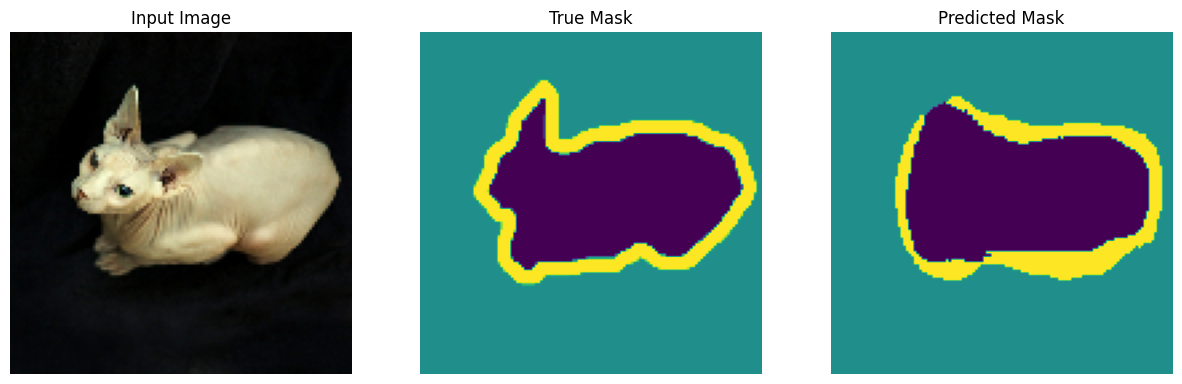


Sample Prediction after epoch 7

920/920 [==============================] - 16s 17ms/step - loss: 0.4529 - accuracy: 0.8124 - val_loss: 0.4925 - val_accuracy: 0.7957
Epoch 8/20
917/920 [============================>.] - ETA: 0s - loss: 0.4135 - accuracy: 0.8280

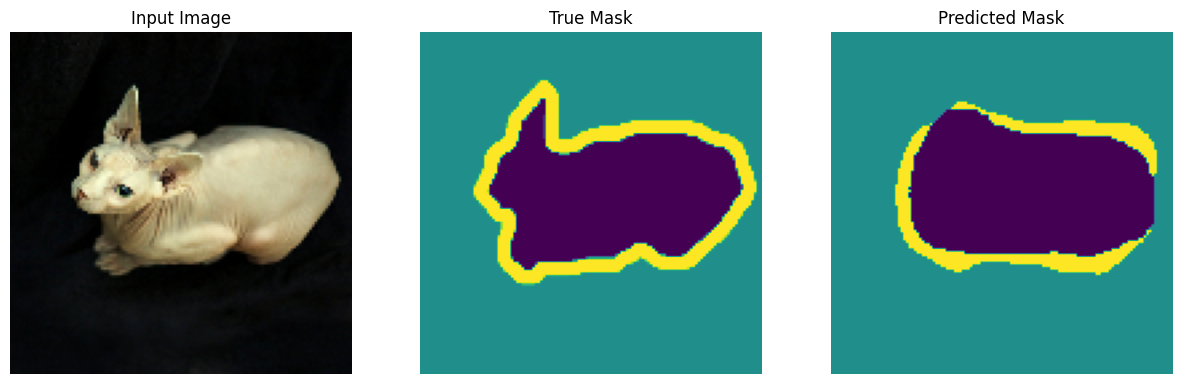


Sample Prediction after epoch 8

920/920 [==============================] - 16s 17ms/step - loss: 0.4135 - accuracy: 0.8280 - val_loss: 0.4949 - val_accuracy: 0.7979
Epoch 9/20
919/920 [============================>.] - ETA: 0s - loss: 0.3747 - accuracy: 0.8428

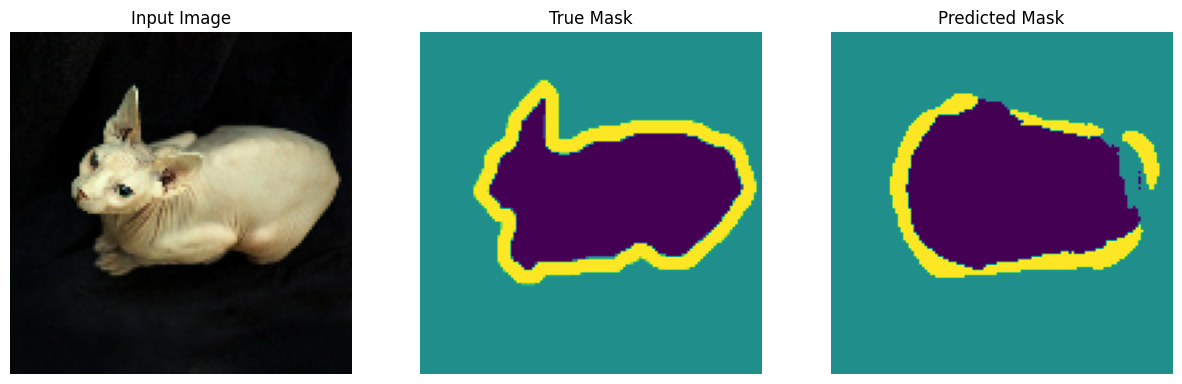


Sample Prediction after epoch 9

920/920 [==============================] - 16s 17ms/step - loss: 0.3747 - accuracy: 0.8428 - val_loss: 0.5130 - val_accuracy: 0.7950
Epoch 10/20
920/920 [==============================] - ETA: 0s - loss: 0.3340 - accuracy: 0.8581

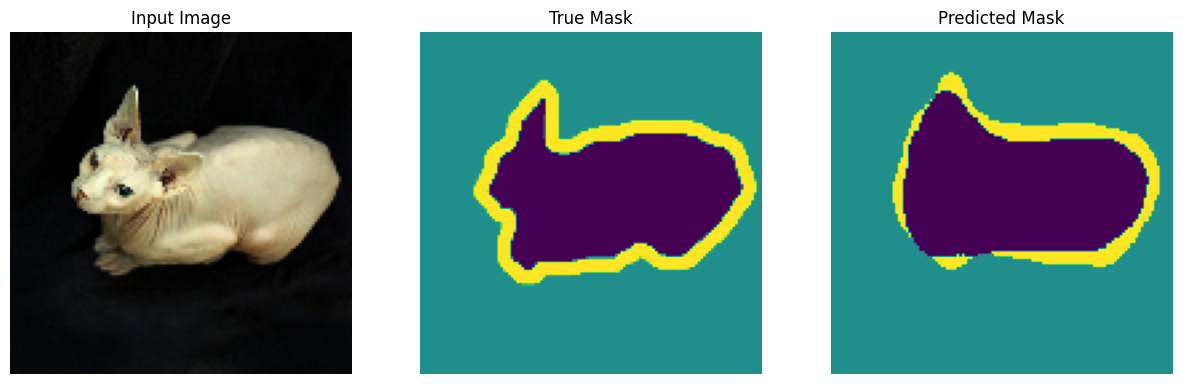


Sample Prediction after epoch 10

920/920 [==============================] - 16s 17ms/step - loss: 0.3340 - accuracy: 0.8581 - val_loss: 0.5145 - val_accuracy: 0.7994
Epoch 11/20
920/920 [==============================] - ETA: 0s - loss: 0.2998 - accuracy: 0.8705

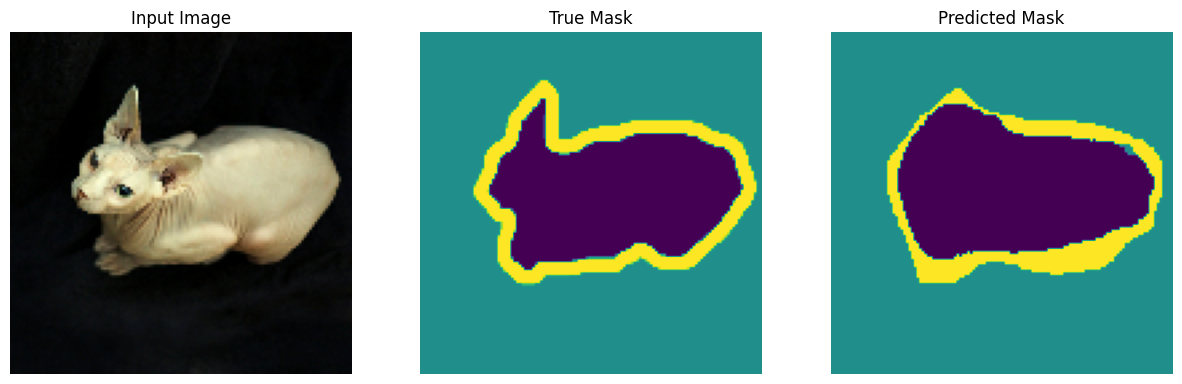


Sample Prediction after epoch 11

920/920 [==============================] - 16s 17ms/step - loss: 0.2998 - accuracy: 0.8705 - val_loss: 0.6344 - val_accuracy: 0.7817
Epoch 12/20
920/920 [==============================] - ETA: 0s - loss: 0.2755 - accuracy: 0.8795

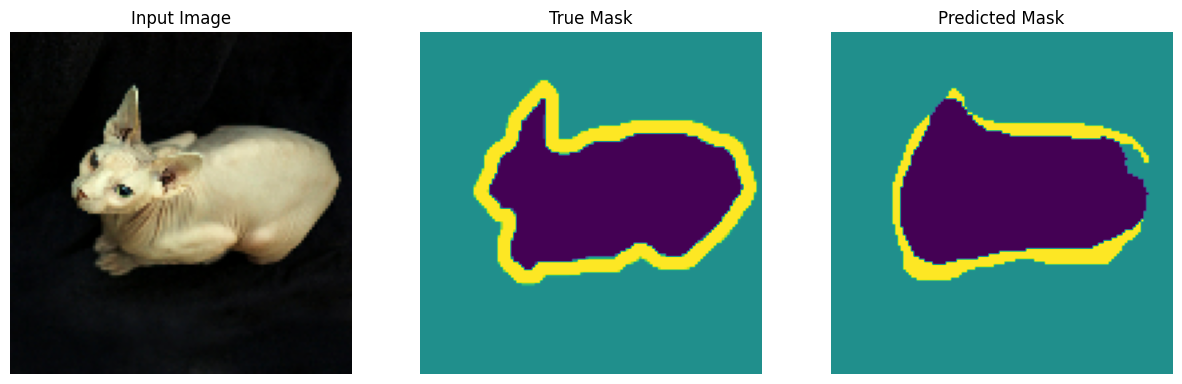


Sample Prediction after epoch 12

920/920 [==============================] - 16s 17ms/step - loss: 0.2755 - accuracy: 0.8795 - val_loss: 0.5559 - val_accuracy: 0.7887
Epoch 13/20
920/920 [==============================] - ETA: 0s - loss: 0.2620 - accuracy: 0.8847

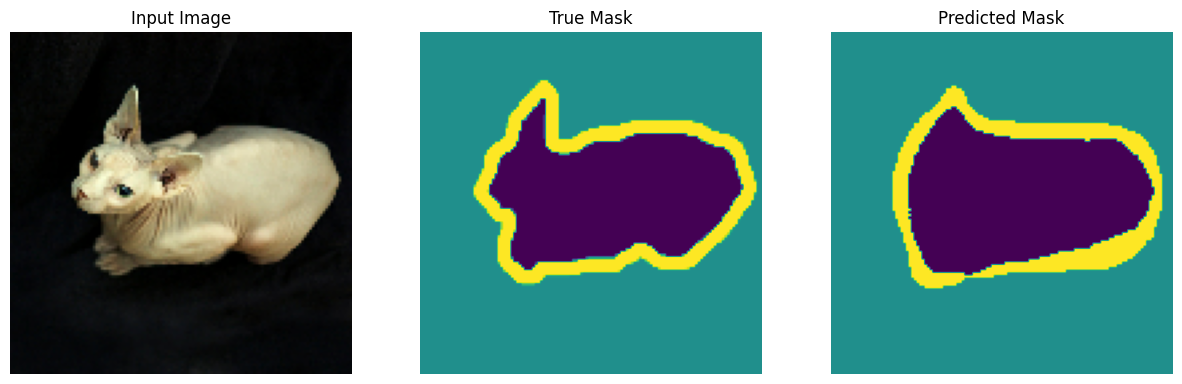


Sample Prediction after epoch 13

920/920 [==============================] - 16s 17ms/step - loss: 0.2620 - accuracy: 0.8847 - val_loss: 0.5136 - val_accuracy: 0.8033
Epoch 14/20
917/920 [============================>.] - ETA: 0s - loss: 0.2347 - accuracy: 0.8952

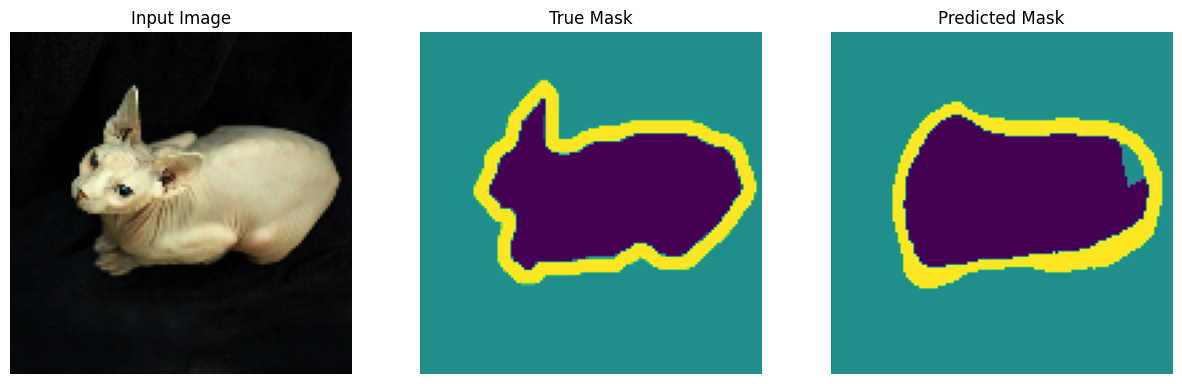


Sample Prediction after epoch 14

920/920 [==============================] - 16s 17ms/step - loss: 0.2346 - accuracy: 0.8953 - val_loss: 0.5450 - val_accuracy: 0.8103
Epoch 15/20
920/920 [==============================] - ETA: 0s - loss: 0.2241 - accuracy: 0.8997

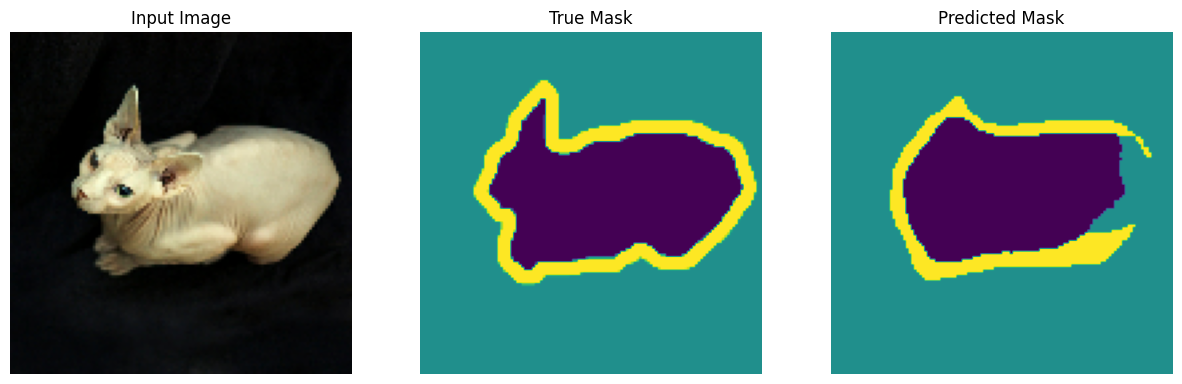


Sample Prediction after epoch 15

920/920 [==============================] - 16s 17ms/step - loss: 0.2241 - accuracy: 0.8997 - val_loss: 0.5630 - val_accuracy: 0.8066
Epoch 16/20
918/920 [============================>.] - ETA: 0s - loss: 0.2094 - accuracy: 0.9054

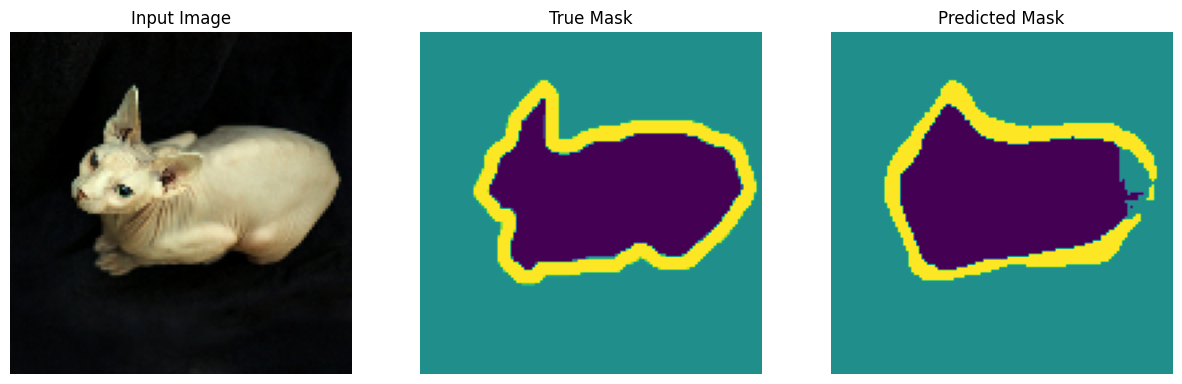


Sample Prediction after epoch 16

920/920 [==============================] - 16s 17ms/step - loss: 0.2095 - accuracy: 0.9054 - val_loss: 0.5904 - val_accuracy: 0.8104
Epoch 17/20
920/920 [==============================] - ETA: 0s - loss: 0.1998 - accuracy: 0.9093

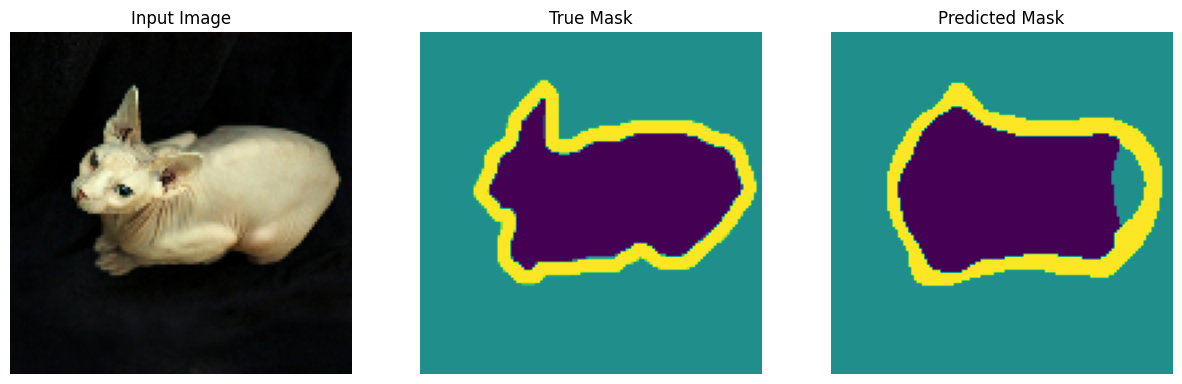


Sample Prediction after epoch 17

920/920 [==============================] - 16s 18ms/step - loss: 0.1998 - accuracy: 0.9093 - val_loss: 0.5694 - val_accuracy: 0.8064
Epoch 18/20
920/920 [==============================] - ETA: 0s - loss: 0.1931 - accuracy: 0.9122

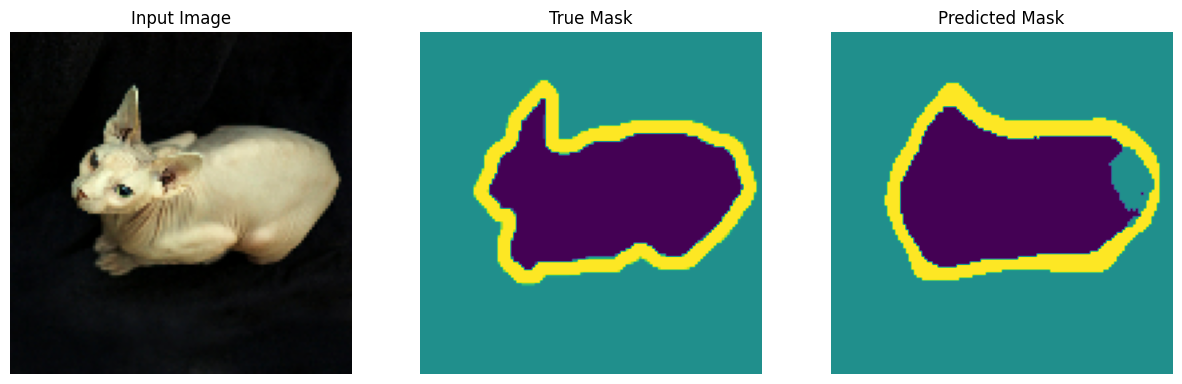


Sample Prediction after epoch 18

920/920 [==============================] - 16s 17ms/step - loss: 0.1931 - accuracy: 0.9122 - val_loss: 0.6473 - val_accuracy: 0.7975
Epoch 19/20
917/920 [============================>.] - ETA: 0s - loss: 0.1845 - accuracy: 0.9160

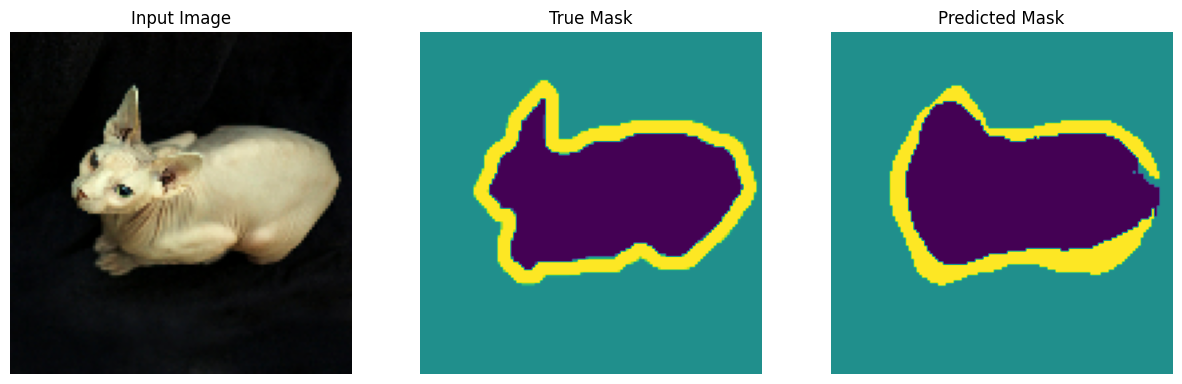


Sample Prediction after epoch 19

920/920 [==============================] - 16s 17ms/step - loss: 0.1845 - accuracy: 0.9160 - val_loss: 0.5904 - val_accuracy: 0.8145
Epoch 20/20
920/920 [==============================] - ETA: 0s - loss: 0.1751 - accuracy: 0.9200

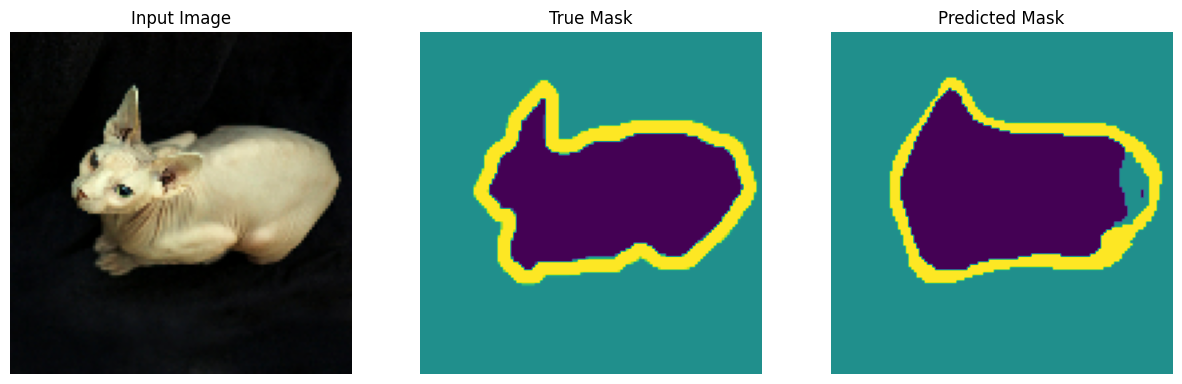


Sample Prediction after epoch 20

920/920 [==============================] - 16s 17ms/step - loss: 0.1751 - accuracy: 0.9200 - val_loss: 0.7071 - val_accuracy: 0.8080


In [12]:
EPOCHS = 20
VAL_SUBSPLITS = 5
VALIDATION_STEPS = info.splits['test'].num_examples//BATCH_SIZE//VAL_SUBSPLITS

model_history = model.fit(train_dataset, epochs=EPOCHS,
                          steps_per_epoch=STEPS_PER_EPOCH,
                          validation_steps=VALIDATION_STEPS,
                          validation_data=test_dataset,
                          callbacks=[DisplayCallback()])

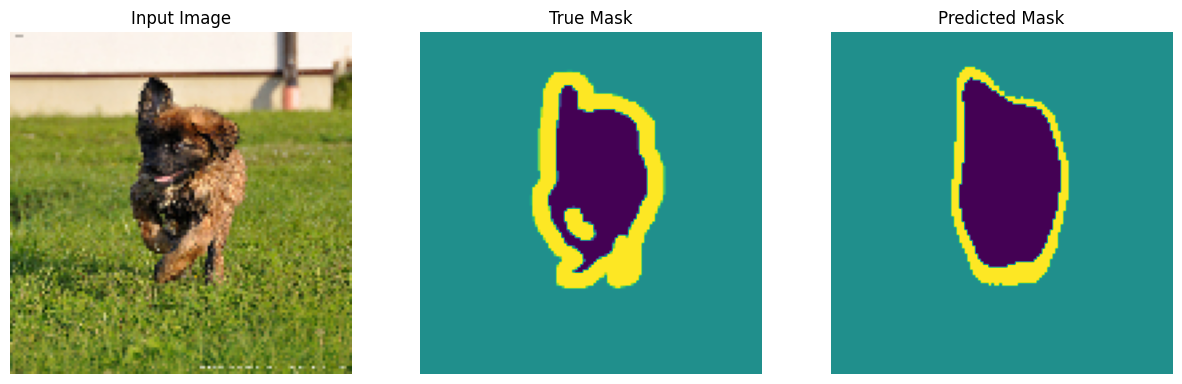

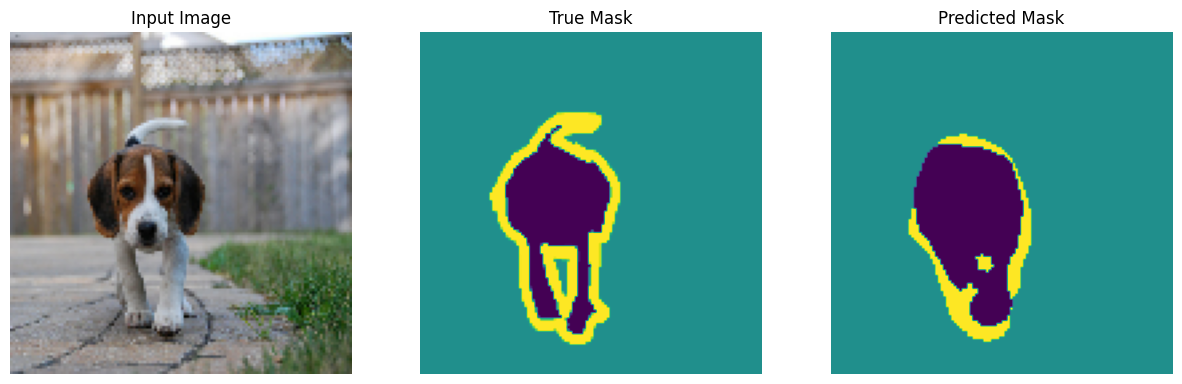

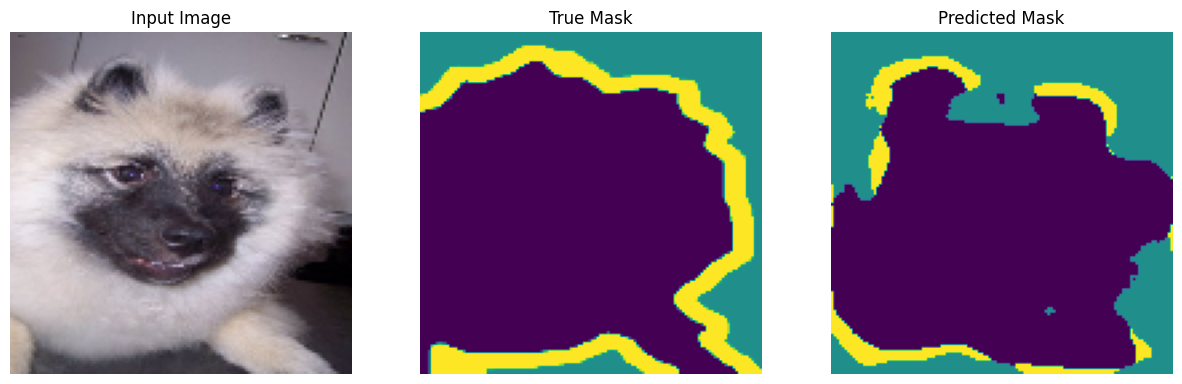

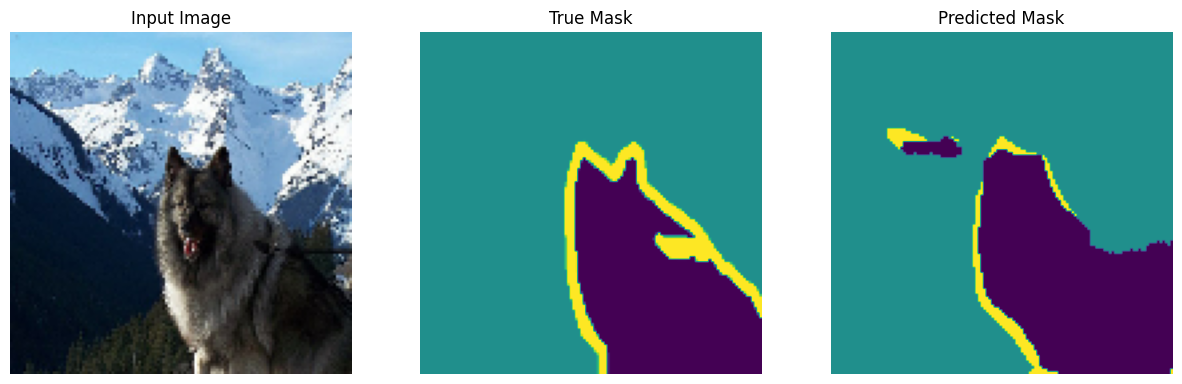

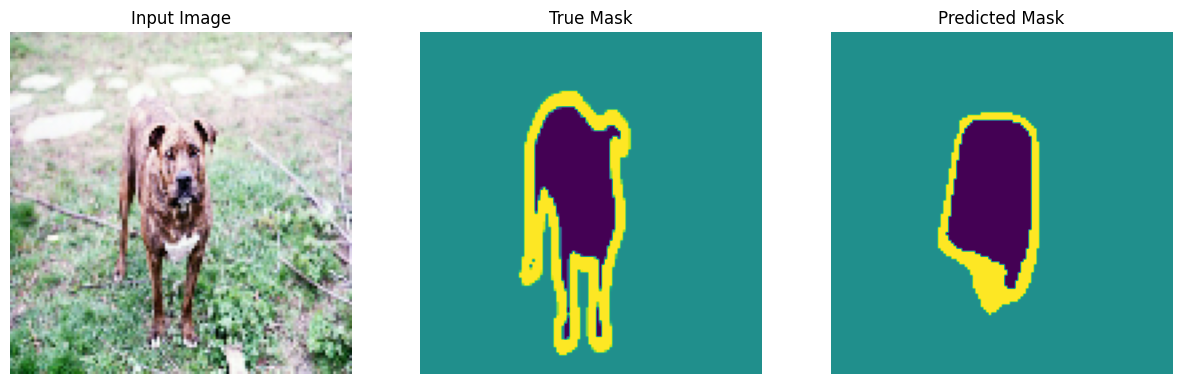

In [13]:
show_predictions(test_dataset, 5)